In [277]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score , roc_curve
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score



**1.Data Loading & Initial Inspection**

Load the WA_Fn-UseC_-Telco-Customer-Churn dataset into a pandas DataFrame.

In [279]:
#Load the dataset
data=pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [280]:
#Display the first five rows to get an initial look at the dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [281]:
#Display all column names
list(data.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [282]:
#Check the data types and non-null values for each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We notice that TotalCharges is stored as an object data type, even if it represents numerical values. Therefore it needs to be 
converted to a numeric data typy 

In [284]:
#Convert Total charges to numeric format
#Invalid or empty values are converted to Nan

data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')

In [285]:
#Generate descriptive statistics for numerical variables
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [286]:
#Check for duplicates 
print('Duplicates:',data.duplicated().sum())

Duplicates: 0


In [287]:
#Check the dimensions of the dataset
print('Dataset shape(rows,columns):',data.shape)

Dataset shape(rows,columns): (7043, 21)


In [288]:
#Check the number of missing values in each column
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

After converting TotalCharges to numeric data type we notice that there are 11 missing values, which resulted from invalid
or empty entries 

In [290]:
#Inspect rows with missing TotalCharges values
data[data['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


The missing TotalCharges values correspond to customers with a tenure with 0 months.Since these are newly joined customers who have 
not accumulated any charges we replace the missing value with 0

In [292]:
#Replace missing TotalCharges values with 0
data['TotalCharges']=data['TotalCharges'].fillna(0)

In [293]:
#Inspect customers with 0 tenure
data[data['tenure']==0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [294]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [295]:
#Convert SeniorCitizen to a categorical variable
data['SeniorCitizen']=data['SeniorCitizen'].map({1:'Yes',0:'No'})

In [296]:
#Check the number of customers in each category
data['SeniorCitizen'].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

**2. SQLite Database Integration**

To demonstrate basic SQL and database skills, the cleaned customer dataset is stored in a local SQLite database.

The dataset is stored as a table named customers, allowing customer information to be queried using SQL. A small number of SQL queries are used 
to retrieve customer information and calculate churn-related statistics.

The main exploratory analysis and machine learning workflow will continue to use pandas and scikit-learn.

In [298]:
# Create a connection to the SQLite database
conn = sqlite3.connect("data/telco_churn.db")

In [299]:
# Store the cleaned dataset as a table named customers
data.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

7043

In [300]:
# Check the tables available in the SQLite database
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,customers


In [301]:
# Retrieve the first five customers from the SQLite database
query="""
SELECT*
FROM customers
LIMIT 5
"""

pd.read_sql(query,conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [302]:
# Count the total number of customers
query="""
SELECT COUNT(*) AS TotalCustomers
FROM customers
"""

pd.read_sql(query,conn)

,TotalCustomers
0,7043


In [303]:
# Count customers by contract type
query="""
SELECT
    Contract,
    COUNT(*) AS CustomerCount
FROM customers
GROUP BY Contract
"""

contract_count_sql=pd.read_sql(query,conn)

contract_count_sql


,Contract,CustomerCount
0,Month-to-month,3875
1,One year,1473
2,Two year,1695


In [304]:
# Calculate the churn rate for each contract type
query="""
SELECT
    Contract,
    COUNT(*) AS CustomerCount,
    AVG(
        CASE
            WHEN Churn ='Yes' THEN 1.0
            ELSE 0.0
        END
    )*100 AS ChurnRate
FROM customers
GROUP BY Contract
ORDER BY ChurnRate DESC
"""

contract_churn_sql=pd.read_sql(query,conn)
contract_churn_sql

,Contract,CustomerCount,ChurnRate
0,Month-to-month,3875,42.709677
1,One year,1473,11.269518
2,Two year,1695,2.831858


In [305]:
# Close the SQLite database connection
conn.close

<function Connection.close()>

**3. Exploratory Data Analysis (EDA)**

Explore the dataset to understand customer characteristics, churn distribution, and important patterns in the data.

**3.1 Churn Distribution**

We first examine the distribution of the target variable (Churn), to understand the proportion of customers who stayed or left.
The dataset contains approximately 73.46% customers who did not churn and 26.54% who churned. We see that the target variable is imbalanced ,with significanlty
more non-churn customers

In [308]:
print(data['Churn'].value_counts(normalize=True).mul(100).round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [309]:
#Calculate the % of churned and non-churned customers across the different contract types
Contract_churn=data.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [310]:
Contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


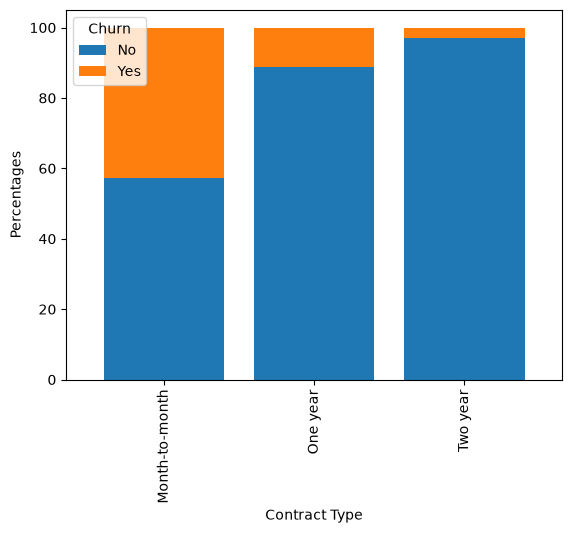

In [311]:
#Plot churn % by contract type
Contract_churn.plot(kind='bar',stacked=True,width=0.8)
plt.xlabel('Contract Type')
plt.ylabel('Percentages')
plt.show()

Observation

The Churn rate varies across contract types. Customers with month-to-month contracts have the highest churn rate at 42.71% ,while
customers with One year and Two year contracts have much lower Churn rates 

**3.2 Customer tenure analysis**

Customer tenure represent the number of months a customer has been with the company


In [314]:
#Display discriptive statistics for customer tenure
data['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

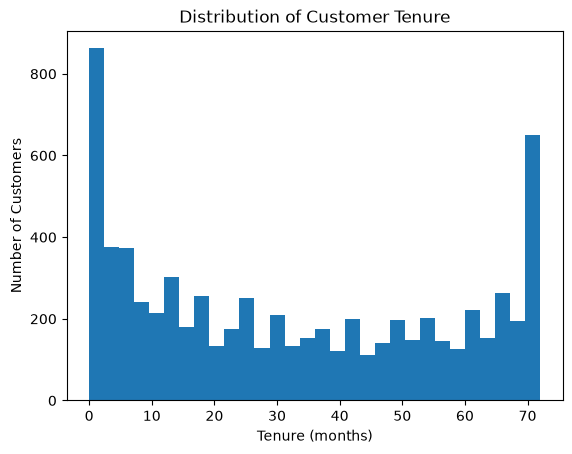

In [315]:
data["tenure"].plot(kind="hist", bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

In [316]:
#Calculating the percentage of churned and non-churned customers for each tenure period
tenure_churn=data.groupby('tenure')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [317]:
tenure_churn

Churn,No,Yes
tenure,,
0,100.000000,NaN
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


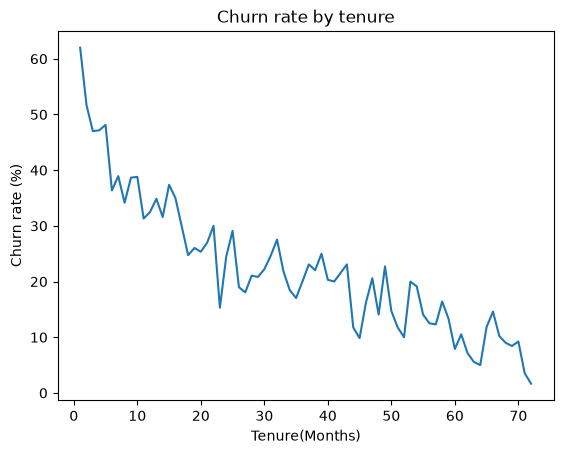

In [318]:
#Plot the churn rate for each tenure period
tenure_churn['Yes'].plot()
plt.xlabel('Tenure(Months)')
plt.ylabel('Churn rate (%)')
plt.title('Churn rate by tenure')
plt.show()

Observation

The Churn rate generally decreases as cistomer tenure increases. Although there are some fluctuations across individual tenure
periods, the overall trend shows that customers with shorter tenure are mor elikely to churn, while customers who have been with 
the company longer tend to have lower churn rates.

In [320]:
# Divide MonthlyCharges into three categories based on the selected ranges
data["MonthlyChargesSegment"] = pd.cut(
    data["MonthlyCharges"],
    bins=[-float("inf"), 35.5, 89.85, float("inf")],
    labels=["Low", "Medium", "High"]
)

**3.3 Monthly charges segmentation**

To make the MonthlyCharges easier to analyze , we divide customers into three groups based on their Monthly Charges:Low, Medium,High

In [322]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyChargesSegment
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Medium


In [323]:
#Calculate the percentage of the churned and non-churned customers
#within each monthly charges segment
monthly_charges_churn = (
    data.groupby("MonthlyChargesSegment")["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

C:\Users\korel\AppData\Local\Temp\ipykernel_16540\2251487021.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("MonthlyChargesSegment")["Churn"]


In [324]:
monthly_charges_churn

Churn,No,Yes
MonthlyChargesSegment,,
Low,88.762770,11.237230
Medium,68.975305,31.024695
High,67.121729,32.878271


Observation

The churn rate is substantially higher among customers with medium and highly monthly charges compared with customers with
low montlhy charges.
Customers with Low montlhy charges segment have a churn rate of 11.24 , compared with 31.02 for the Medium segment and 32.88 for the High segment.
This suggests that customers with higher monthly charges are more likely to churn.

Distribution of Monthly charges 
To further investigate the relationship between monthly charges and churn, we compare the distribution of MontlhyCharges for churned 
and non-churned customers.
The KDE plot shows were monthly charge values are more concentrated for each churn group.

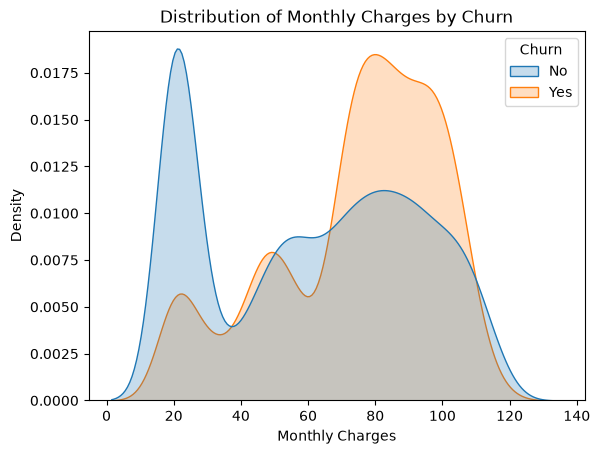

In [327]:
sns.kdeplot(data=data, x="MonthlyCharges", hue="Churn",fill=True,common_norm=False)
plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()



Observation

The distribution shows that churned customers tend to have higher monthly charges compared to non-churned. There is still 
considerable overlap between the two groups, indicating that monthly charges alone do not fully explain customer churn.

Churn rate by internet service
We examine the relationship between internet service type and customer churn by calculating the percenatge of churned and non-churned 
customers within each internet service category

**3.4 Churn rate by Internet service**

We examine the relationship between internet service type and customer churn by calculating the percentage of churned and non-churned customers 
within each internet service category.

In [331]:
internet_service_churn=data.groupby('InternetService')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [332]:
internet_service_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


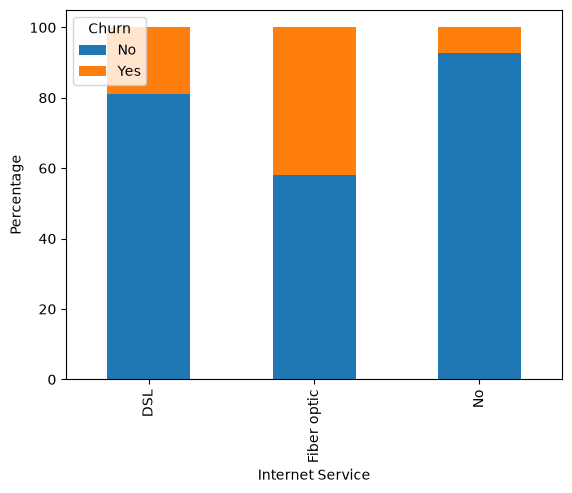

In [333]:
internet_service_churn.plot(kind='bar',stacked=True)
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.show()

Observation

Churn rates vary considerably across internet service types. Customers with fiber optic service have the highest churn rate 
at 41.89%, compared with 18.96% for DSL and 7.40% for customers without internet service.
This suggests that customers with fiber optic service represent a higher-risk group for churn.

Churn rate by contract and Internet Service
We examine the combined relationship between contract type , internet service and customer churn.
By calculating the churn percentage within each contract the internet service combination, we can identify 
customer groups with particularly high or low churn rates.

**3.5 Churn Rate by Contract and Internet Service**

We examine the combined relationship between contract type, internet service, and customer churn.

By calculating the churn percentage within each contract and internet service combination, we can identify customer groups with particularly high 
or low churn rates.

In [337]:
contract_internet_churn=data.groupby(['Contract','InternetService'])['Churn'].value_counts(normalize=True).mul(100).unstack()

In [338]:
contract_internet_churn

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

Observation

Churn rates vary substantially depending on both contract type and internet service.
The highest churn rate is observed among customers with month-to-month contracts and fiber optic service,where approximately
54.61% of customers churned.In contrast , customers with two-year contracts have very low churn rate across all internet service
types,with the lowest rate observed among customers without internet service at approximately 0.78%.
Overall,this suggests that the combination of contract type and internet service can help identify customer groups with different 
levels of churn rates.


**3.6 Churn Rate by Payment Method**

We examine the relationship between payment method and customer churn by calculating the percentage of churned and non-churned 
customers within each payment method.

In [341]:
payment_churn=data.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [342]:
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


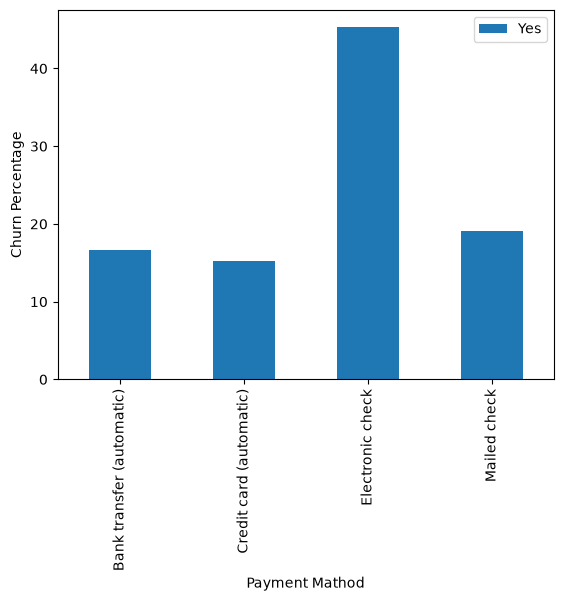

In [343]:
payment_churn.plot(kind='bar',y='Yes')
plt.xlabel('Payment Mathod')
plt.ylabel('Churn Percentage')
plt.show()

Observation

Churn rates vary considerably across payment methods. Customers using electronic check have the highest churn rate at 45.29%, 
compared with 19.11% for mailed check, 16.71% for automatic bank transfer, and 15.24% for automatic credit card payments.

This suggests that customers using electronic check represent a higher-risk group for churn compared with customers using other payment methods.

**3.7 Churn Rate by Payment Method and Contract**

We further examine the combined relationship between payment method, contract type, and customer churn.

By calculating churn rates for each payment method and contract combination, we can identify customer groups with particularly high churn rates.

In [346]:
payment_contract_churn=data.groupby(['PaymentMethod','Contract'])['Churn'].value_counts(normalize=True).mul(100).unstack()

In [347]:
payment_contract_churn

Churn                                            No        Yes
PaymentMethod             Contract                            
Bank transfer (automatic) Month-to-month  65.874363  34.125637
                          One year        90.281330   9.718670
                          Two year        96.631206   3.368794
Credit card (automatic)   Month-to-month  67.219153  32.780847
                          One year        89.698492  10.301508
                          Two year        97.762478   2.237522
Electronic check          Month-to-month  46.270270  53.729730
                          One year        81.556196  18.443804
                          Two year        92.261905   7.738095
Mailed check              Month-to-month  68.421053  31.578947
                          One year        93.175074   6.824926
                          Two year        99.214660   0.785340

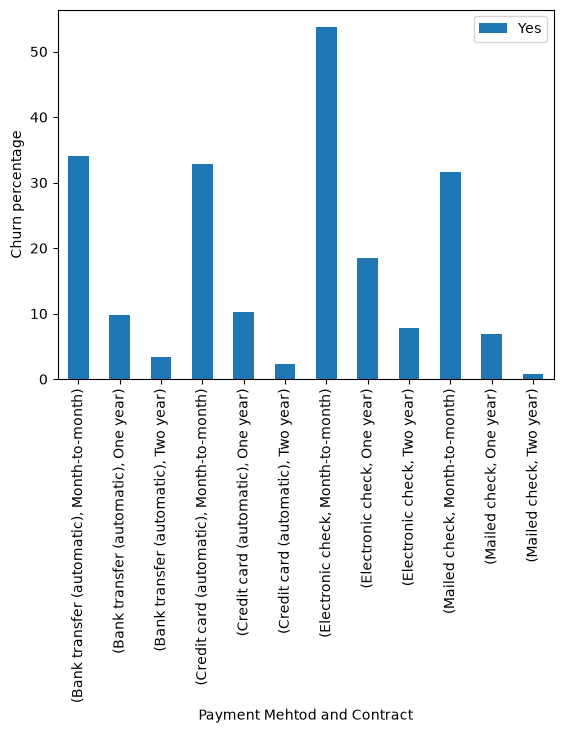

In [348]:
payment_contract_churn.plot(kind='bar',y='Yes')
plt.xlabel('Payment Mehtod and Contract')
plt.ylabel('Churn percentage')
plt.show()

Observation

Churn rates vary considerably across combinations of payment method and contract type.
The highest churn rate is observed among customers using electronic check with a month-to-month contract, where approximately 53.73% 
of customers churned. In comparison, customers with two-year contracts have substantially lower churn rates across all payment methods.

This suggests that customers combining a month-to-month contract with electronic check payment represent a particularly high-risk group for churn.

**3.8 Churn Rate by Online Security**

We examine the relationship between online security service and customer churn by calculating the percentage of churned and non-churned 
customers within each online security category.

In [351]:
onlinesecurity_churn=data.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [352]:
onlinesecurity_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


Observation

Churn rates differ substantially depending on whether customers have an online security service.

Customers without online security have the highest churn rate at 41.77%, compared with 14.61% for customers with online security. 
Customers with no internet service have the lowest churn rate at 7.40%.
This suggests that customers without online security represent a higher-risk group for churn

**3.9 Churn Rate by Online Backup**

We examine the relationship between online backup service and customer churn by calculating the percentage of churned and non-churned
customers within each online backup category.

In [355]:
onlinebackup_churn=data.groupby('OnlineBackup')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [356]:
onlinebackup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


Observation

Churn rates differ across online backup categories. Customers without online backup have the highest churn rate at 39.93%, 
compared with 21.53% for customers with online backup. Customers with no internet service have the lowest churn rate at 7.40%.
This suggests that customers without online backup represent a higher-risk group for churn.

**3.10 Churn Rate by Device Protection**

We examine the relationship between device protection service and customer churn by calculating the percentage of churned and non-churned 
customers within each device protection category.

In [359]:
deviceprotection_churn=data.groupby('DeviceProtection')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [360]:
deviceprotection_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


Observation

Churn rates differ across device protection categories. Customers without device protection have the highest churn rate at 39.13%, compared 
with 22.50% for customers with device protection. Customers with no internet service have the lowest churn rate at 7.40%.
This suggests that customers without device protection represent a higher-risk group for churn.

**3.11 Churn Rate by Tech Support**

We examine the relationship between technical support service and customer churn by calculating the percentage of churned and non-churned 
customers within each technical support category.

In [363]:
techsupport_churn=data.groupby('TechSupport')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [364]:
techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Observation

Churn rates differ substantially across technical support categories. Customers without technical support have the highest churn rate at 41.64%, 
compared with 15.17% for customers with technical support. Customers with no internet service have the lowest churn rate at 7.40%
This suggests that customers without technical support represent a higher-risk group for churn.

**3.12 Churn Rate by Streaming TV**

We examine the relationship between the streaming TV service and customer churn by calculating the percentage of churned and non-churned 
customers within each streaming TV category.

In [367]:
streamingtv_churn=data.groupby('StreamingTV')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [368]:
streamingtv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


Observation

Churn rates are relatively similar between customers with and without streaming TV. Customers without streaming TV have a churn rate of 33.52%, 
compared with 30.07% for customers with streaming TV. Customers with no internet service have the lowest churn rate at 7.40%.
This suggests that StreamingTV has a weaker relationship with churn compared with some of the other service-related variables examined.

**3.13 Churn Rate by Streaming Movies**

We examine the relationship between the streaming movies service and customer churn by calculating the percentage of churned and non-churned 
customers within each streaming movies category.

In [371]:
movies_churn=data.groupby('StreamingMovies')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [372]:
movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


Observation

Churn rates are relatively similar between customers with and without streaming movies. Customers without streaming movies have a churn rate of 33.68%, 
compared with 29.94% for customers with streaming movies. Customers with no internet service have the lowest churn rate at 7.40%.
This suggests that StreamingMovies has a relatively weak relationship with churn compared with variables such as Contract, InternetService, and TechSupport.

**3.14 Number of Additional Services**

To summarize the customer's use of additional services, we create a new variable called NumServices.
This variable counts how many of the following services each customer has: Online Security, Online Backup, Device Protection, Tech Support, 
Streaming TV, and Streaming Movies.
We then examine whether churn rates vary according to the number of additional services used.

In [375]:
services=['OnlineSecurity',
          'OnlineBackup',
          'DeviceProtection',
          'TechSupport',
          'StreamingTV',
          'StreamingMovies'
         ]

In [376]:
data['NumServices']=(data[services]=='Yes').sum(axis=1)

In [377]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyChargesSegment,NumServices
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low,1
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium,2
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium,2
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium,3
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Medium,0


In [378]:
services_churn=data.groupby('NumServices')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [379]:
services_churn

Churn,No,Yes
NumServices,,
0,78.593961,21.406039
1,54.244306,45.755694
2,64.181994,35.818006
3,72.629696,27.370304
4,77.699531,22.300469
5,87.565674,12.434326
6,94.718310,5.281690


Observation

Churn rates vary considerably according to the number of additional services used.

Customers with only one additional service have the highest churn rate at 45.76%, while customers with six additional services have the lowest 
churn rate at 5.28%. Overall, customers with a larger number of additional services tend to have lower churn rates.

This suggests that customers who use more additional services may be more engaged with the company's offerings and less likely to churn.

**3.15 Churn Rate by Senior Citizen Status**

We examine the relationship between senior citizen status and customer churn by calculating the percentage of churned and non-churned 
customers within each age category.

In [382]:
senior_churn=data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [383]:
senior_churn

Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


Observation

Churn rates differ substantially between senior citizens and non-senior customers. Senior citizens have a churn rate of 41.68%, 
compared with 23.61% for non-senior customers.
This suggests that senior citizens represent a higher-risk group for customer churn.

**3.16 Churn Rate by Partner Status**

We examine the relationship between partner status and customer churn by calculating the percentage of churned and non-churned customers 
within each partner category.

In [386]:
partner_churn=data.groupby('Partner')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [387]:
partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


Observation

Churn rates differ between customers with and without a partner. Customers without a partner have a churn rate of 32.96%, compared with 
19.66% for customers with a partner.
This suggests that customers without a partner represent a higher-risk group for customer churn.

**3.17 Churn Rate by Dependents**

We examine the relationship between dependent status and customer churn by calculating the percentage of churned and non-churned customers 
within each dependent category.

In [390]:
dependends_churn=data.groupby('Dependents')['Churn'].value_counts(normalize=True).mul(100).unstack()

In [391]:
dependends_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Observation

Churn rates differ substantially between customers with and without dependents. Customers without dependents have a churn rate of 31.28%, 
compared with 15.45% for customers with dependents.
This suggests that customers without dependents represent a higher-risk group for customer churn.

**4. Correlation Analysis**

To examine the linear relationships between the numerical and encoded categorical variables, we convert categorical variables into dummy 
variables and calculate their correlations with the target variable, `Churn`.
We then sort the correlations to identify which variables have the strongest positive or negative relationships with churn.

In [394]:
# Create a copy of the dataset for correlation analysis
corr_data=data.copy()

In [395]:
#Remove identifier and EDA-only variables
corr_data = corr_data.drop(["customerID","MonthlyChargesSegment"], axis=1)

In [396]:
# Convert the target variable into binary values
corr_data["Churn"] = corr_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [397]:
# Convert categorical variables into dummy variables
corr_data = pd.get_dummies(corr_data, drop_first=True)

In [398]:
# Calculate the correlation matrix
corr = corr_data.corr()

In [399]:
# Sort correlations with Churn from highest to lowest
churn_corr = corr["Churn"].sort_values(ascending=False)

In [400]:
churn_corr

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen_Yes                        0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
NumServices                             -0.087698
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674


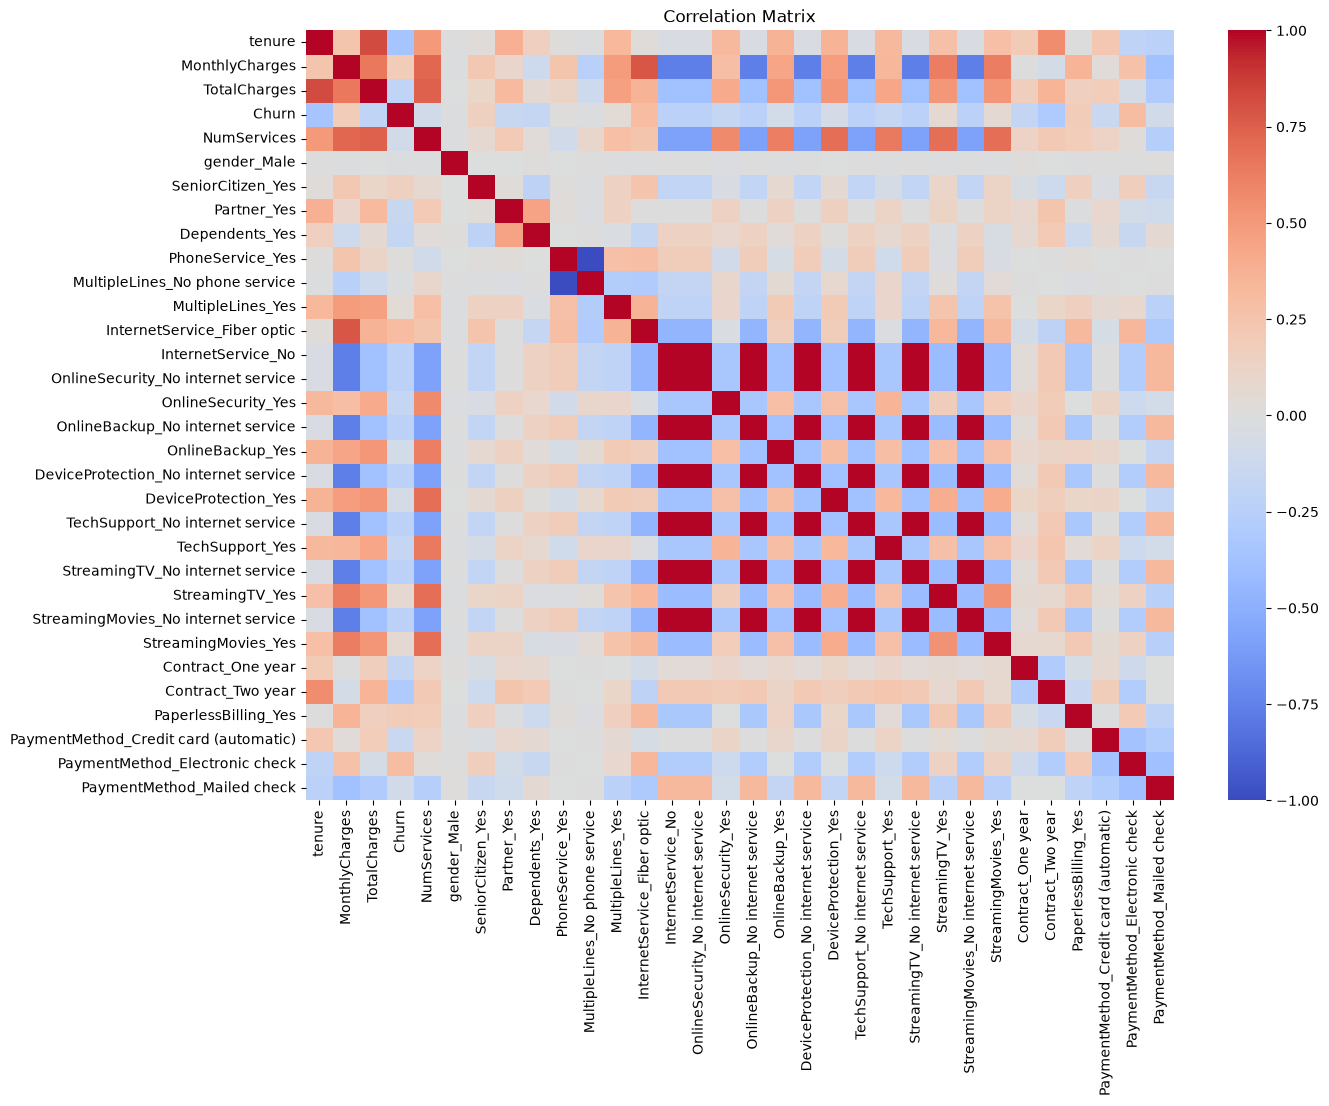

In [401]:
# Create a heatmap to visualize correlations between variables
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Observation

The correlation analysis shows that several variables have noticeable relationships with customer churn.

The strongest positive correlations with churn are observed for fiber optic internet service (0.31), electronic check payment (0.30), 
monthly charges (0.19), and paperless billing (0.19).

On the other hand, tenure (-0.35), two-year contracts (-0.30), and total charges (-0.20) have relatively strong negative correlations with churn. 
Service-related variables such as OnlineSecurity, TechSupport, and OnlineBackup also show negative relationships with churn.

Overall, the correlation analysis supports several patterns identified during EDA, particularly the relationships between churn and contract type, 
tenure, internet service, payment method, and additional services.

These correlations indicate associations rather than causal relationships and will help guide the feature selection and modeling process.

Final EDA Observations

The exploratory data analysis reveals several important patterns associated with customer churn:

- Contract type shows a strong relationship with churn. Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% 
for one-year contracts and only 2.83% for two-year contracts.
- Shorter-tenure customers are more likely to churn. The churn rate generally decreases as customer tenure increases, indicating that newer 
customers represent a higher-risk group.
- Internet service is strongly associated with churn. Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL 
customers and 7.40% for customers without internet service.
- The combination of contract type and internet service reveals particularly high-risk groups. Customers with month-to-month contracts and fiber 
optic service have the highest observed churn rate at approximately 54.61%.
- Payment method is associated with substantial differences in churn. Customers using electronic checks have the highest churn rate at 45.29%, 
considerably higher than customers using automatic payment methods.
- Additional services are associated with lower churn. Customers with more additional services generally show lower churn rates. Customers with 
six additional services have a churn rate of only 5.28%, compared with 45.76% for customers with one additional service.
- Customers without support and security-related services show higher churn. In particular, customers without OnlineSecurity or TechSupport have 
churn rates above 40%, while customers who subscribe to these services have substantially lower churn rates.
- Higher monthly charges are associated with higher churn rates. Customers in the low monthly-charge segment have a churn rate of 11.24%, compared 
with 31.02% for the medium segment and 32.88% for the high segment
- Customer characteristics also show noticeable differences in churn. Senior citizens, customers without partners, and customers without dependents 
have higher churn rates than their respective comparison groups.

Overall, the EDA suggests that contract type, tenure, internet service, payment method, additional services, monthly charges, and customer characteristics
are important factors to consider when modeling customer churn.

**5. Data Preparation for Machine Learning**

5.1 Feature and Target Definition

In [405]:
# Remove the customer identifier, target variable, and EDA-only variable
X=data.drop(columns=['customerID','Churn','MonthlyChargesSegment'])

In [406]:
# Define the target variable by converting Churn into binary values
y=data['Churn'].map({'No':0,'Yes':1})

**5.2 Train-Test split**

In [408]:
# Split the data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)

In [409]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   object 
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

**5.3 Data preprocessing**

In [411]:
# Identify categorical columns in the training data
cat_columns=X_train.select_dtypes(include=['object']).columns

In [412]:
# Define numerical columns for scaling
num_columns = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']

In [413]:
numeric_transformer=StandardScaler() # Standardize numerical features
categorical_transformer=OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

In [414]:
# Combine numerical scaling and categorical encoding into a single preprocessing pipeline
preprocessor=ColumnTransformer(transformers=[('num',numeric_transformer,num_columns),('cat',categorical_transformer,cat_columns)])

**6. Model Training**

6.1 Logistic regression

Logistic Regression is used as the first classification model to establish a baseline for predicting customer churn.
The preprocessing steps are included in the pipeline, ensuring that numerical scaling and categorical encoding are applied 
consistently before training the model.

In [416]:
# Create a pipeline that combines preprocessing and Logistic Regression
log_model=Pipeline([('preprocessor',preprocessor),('model',LogisticRegression(random_state=42))])

In [417]:
log_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [418]:
# Train the model using the training data
log_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'NumServices']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [419]:
# Generate predictions on the test set
y_pred_log=log_model.predict(X_test)

In [420]:
# Evaluate the model using the classification report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [421]:
confusion_matrix(y_test,y_pred_log)

array([[926, 109],
       [165, 209]])

Observation

The Logistic Regression model achieves an overall accuracy of 81%. For customers who churned, the model achieves a precision of 66%, a recall of 56%, 
and an F1-score of 60%.

The model identifies approximately half of the actual churn cases, while maintaining moderate precision. This provides a useful baseline for comparison
with the other classification models that will be trained later.

**6.2 K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) is used as the second classification model. Since KNN is sensitive to the scale of numerical features, 
the preprocessing pipeline applies standardization before the model is trained.

The number of neighbors is treated as a hyperparameter. We use GridSearchCV with 5-fold cross-validation to evaluate values from 1 to 30 and 
select the value that produces the best F1-score.

In [424]:
# Define the range of n_neighbors values to evaluate
knc_param_grid={'model__n_neighbors':range(1,31)}

In [425]:
# Create a pipeline combining preprocessing and KNN
knn_pipeline=Pipeline([('preprocessor',preprocessor),('model',KNeighborsClassifier())])

In [426]:
# Perform 5-fold cross-validation to find the best number of neighbors using F1-score as the evaluation metric
grid_knn=GridSearchCV(knn_pipeline,knc_param_grid,cv=5,scoring='f1')

In [427]:
# Train the models and perform hyperparameter tuning
grid_knn.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': range(1, 31)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [428]:
# Generate predictions using the best KNN model
y_pred_knn = grid_knn.predict(X_test)

In [429]:
# Evaluate the model on the test set
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.59      0.56      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.78      1409



Observation

The KNN model achieves an overall accuracy of 78%. For customers who churned, the model achieves a precision of 59%, a recall of 56%, and 
an F1-score of 57%.

Compared with Logistic Regression, KNN achieves a slightly higher recall and F1-score for the churn class, but a slightly lower overall accuracy. 
This indicates that KNN identifies somewhat more churn cases while maintaining similar overall performance.

**6.3 Support Vector Classifier**

Support Vector Classification (SVC) is used as the third classification model. We use an RBF kernel, which can capture non-linear 
relationships between the features and customer churn.

The hyperparameters C and gamma are tuned using 5-fold cross-validation, with the F1-score used as the optimization metric.

In [432]:
# Define the hyperparameter values to evaluate
SVC_param_grid={'model__C':[0.1,1,10,100],'model__gamma':[0.1,1,10,100]}

In [433]:
# Create a pipeline combining preprocessing and SVC
SVC_pipeline=Pipeline([('preprocessor',preprocessor),('model',SVC(kernel='rbf'))])

In [434]:
# Perform 5-fold cross-validation to find the best combination of C and gamma using F1-score
grid_SVC=GridSearchCV(SVC_pipeline,SVC_param_grid,cv=5,scoring='f1')

In [435]:
# Train the models and perform hyperparameter tuning
grid_SVC.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

In [436]:
# Generate predictions using the best SVC model
y_pred_SVC = grid_SVC.predict(X_test)

In [437]:
# Evaluate the model on the test set
print(classification_report(y_test, y_pred_SVC))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Observation

The SVC model achieves an overall accuracy of 79%. For customers who churned, the model achieves a precision of 63%, a recall of 49%, and 
an F1-score of 56%.

The model provides similar overall performance to Logistic Regression, but its recall for the churn class is lower. 
This means that SVC correctly identifies fewer of the customers who actually churned.

Among the three models evaluated so far, KNN has the highest churn recall and F1-score, while Logistic Regression and SVC achieve slightly 
higher overall accuracy.

**6.4 Decision Tree**

A Decision Tree is used to model customer churn by learning a series of decision rules based on the input features.

To improve the model's performance and control its complexity, we tune max_depth, min_samples_split, and min_samples_leaf using 5-fold cross-validation. 
The F1-score is used as the optimization metric.

In [440]:
# Define the hyperparameter values to evaluate
dt_param_grid={'model__max_depth':[3,5,7,10,None],'model__min_samples_split':[2,5,10],
               'model__min_samples_leaf':[1,2,5]}

In [441]:
# Create a pipeline combining preprocessing and Decision Tree
dt_pipeline=Pipeline([('preprocessor',preprocessor),('model',DecisionTreeClassifier())])

In [442]:
# Perform 5-fold cross-validation to find the best combination of hyperparameters using F1-score
grid_dt=GridSearchCV(dt_pipeline,dt_param_grid,cv=5,scoring='f1')

In [443]:
# Train the models and perform hyperparameter tuning
grid_dt.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

In [444]:
# Generate predictions using the best Decision Tree model
y_pred_dt = grid_dt.predict(X_test)

In [445]:
# Evaluate the model on the test set
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Observation

The Decision Tree model achieves an overall accuracy of 80%. For customers who churned, the model achieves a precision of 69%, a recall of 57%, 
and an F1-score of 60%.

The model performs similarly to SVC in terms of churn F1-score, but its precision is slightly lower. Compared with KNN, the Decision Tree identifies 
fewer churn cases and achieves a lower F1-score.

Overall, the Decision Tree provides reasonable performance but does not outperform the models evaluated so far.

**6.5 Random Forest**

Random Forest is used as an ensemble classification model that combines multiple decision trees to improve predictive performance and reduce 
the risk of overfitting.

The hyperparameters n_estimators, max_depth, and min_samples_leaf are tuned using 5-fold cross-validation, with the F1-score used as 
the optimization metric.

In [448]:
rf_param_grid={'model__n_estimators':[100,200],
               'model__max_depth':[None,5,10],
               'model__min_samples_leaf':[1,2]}

In [449]:
rf_pipeline=Pipeline([('preprocessor',preprocessor),('model',RandomForestClassifier(random_state=42))])

In [450]:
grid_rf=GridSearchCV(rf_pipeline,rf_param_grid,cv=5,scoring='f1',n_jobs=-1)

In [451]:
grid_rf.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [452]:
y_pred_rf=grid_rf.predict(X_test)

In [453]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Observation

The Random Forest model achieves an overall accuracy of 80%. For customers who churned, the model achieves a precision of 67%, a recall 
of 53%, and an F1-score of 59%.

The model achieves slightly higher precision than Logistic Regression and Decision Tree, but its recall for the churn class remains relatively low. 
Its F1-score is also slightly below that of KNN.

Overall, Random Forest provides solid performance, but it does not clearly outperform the models evaluated so far.

**6.6 Gradient Boosting**

Gradient Boosting is an ensemble classification model that builds a sequence of decision trees, where each new tree attempts to improve 
the errors made by the previous trees.

We tune n_estimators, learning_rate, max_depth, and min_samples_leaf using 5-fold cross-validation. The F1-score is used as the optimization metric.

In [456]:
param_grid_gb={'model__n_estimators':[100,200],
               'model__learning_rate':[0.01,0.1],
               'model__max_depth':[3,5],
               'model__min_samples_leaf':[1,2]
              }

In [457]:
gb_pipeline=Pipeline([('preprocessor',preprocessor),('model',GradientBoostingClassifier(random_state=42))])

In [458]:
grid_gb=GridSearchCV(gb_pipeline,param_grid_gb,cv=5,scoring='f1',n_jobs=-1)

In [459]:
grid_gb.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [460]:
y_pred_gb=grid_gb.predict(X_test)

In [461]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Observation

The Gradient Boosting model achieves an overall accuracy of 80%, which is the highest accuracy among the models evaluated so far. For customers who churned, 
the model achieves a precision of 66%, a recall of 52%, and an F1-score of 59%.

Compared with the other models evaluated so far, Gradient Boosting provides competitive overall performance, with the **highest accuracy shared with 
Random Forest**. Its churn F1-score is also competitive, although the Decision Tree and Logistic Regression achieve slightly higher values.

Overall, Gradient Boosting provides strong and balanced performance among the individual models evaluated and will be considered as a candidate for the final model.

**6.7 ROC-AUC Comparison**

ROC-AUC is used to evaluate how well each model distinguishes between churned and non-churned customers across different classification thresholds.

The ROC-AUC score ranges from 0.5, representing random classification, to 1.0, representing perfect discrimination. Higher values indicate better 
ability to distinguish between the two classes.

In [464]:
# Obtain probability scores for each model
y_prob_log=log_model.predict_proba(X_test)[:,1]
y_prob_knn=grid_knn.predict_proba(X_test)[:,1]
y_prob_SVC=grid_SVC.decision_function(X_test)
y_prob_dt=grid_dt.predict_proba(X_test)[:,1]
y_prob_rf=grid_rf.predict_proba(X_test)[:,1]
y_prob_gb=grid_gb.predict_proba(X_test)[:,1]


In [465]:
# Calculate the ROC-AUC score for each model
auc_results={
    'Logistic Regression': roc_auc_score(y_test,y_prob_log),
    'KNN': roc_auc_score(y_test,y_prob_knn),
    'SVC':roc_auc_score(y_test,y_prob_SVC),
    'Decision Tree':roc_auc_score(y_test,y_prob_dt),
    'Random Forest':roc_auc_score(y_test,y_prob_rf),
    'Gradient Boosting':roc_auc_score(y_test,y_prob_gb)
}

In [466]:
# Create a DataFrame and sort models by ROC-AUC
auc_df=pd.DataFrame(auc_results.items(),
                    columns=['Model','ROC-AUC']).sort_values('ROC-AUC',ascending=False)

In [467]:
auc_df

,Model,ROC-AUC
5,Gradient Boosting,0.842631
0,Logistic Regression,0.841988
4,Random Forest,0.838437
3,Decision Tree,0.830432
1,KNN,0.823789
2,SVC,0.789630


Observation

The ROC-AUC results show that **Gradient Boosting achieves the highest score at 0.843**, followed closely by **Logistic Regression at 0.842** and 
**Random Forest at 0.838**.

Decision Tree achieves a ROC-AUC of **0.830**, followed by KNN at **0.824**, while SVC has the lowest score at **0.790**.

Overall, Gradient Boosting demonstrates the strongest ability to distinguish between churned and non-churned customers among the models evaluated. However, its performance is very close to Logistic Regression and Random Forest.

**6.8 Voting Classifier**

To combine the strengths of the best-performing individual models, we create a soft Voting Classifier using Gradient Boosting, Random Forest, 
and Logistic Regression.

With soft voting, the classifier combines the probability predictions from the individual models and uses them to make the final prediction.

The Voting Classifier is then evaluated on the test set using the same classification metrics as the individual models.

In [470]:
# Combine the selected models using soft voting
vclf=VotingClassifier(estimators=[('GB',grid_gb.best_estimator_),('RF',grid_rf.best_estimator_),('Log_model',log_model)],voting='soft')

In [471]:
# Train the Voting Classifier
vclf.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('GB', ...), ('RF', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'NumServices']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [472]:
# Generate predictions on the test set
y_pred_voting = vclf.predict(X_test)

In [473]:
# Evaluate the Voting Classifier
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Observation

The Voting Classifier achieves an overall accuracy of **80%**. For customers who churned, it achieves a precision of **66%**, a recall of **53%**, 
and an F1-score of **59%**.

Its performance is very similar to Gradient Boosting, with the same overall accuracy and churn precision, while achieving a slightly higher recall and F1-score.

Therefore, combining the models through soft voting does not provide a meaningful improvement over the best individual models. However, the Voting 
Classifier provides a competitive alternative by combining predictions from multiple models.

**7. Confusion Matrix — Gradient Boosting**

To further evaluate the final Gradient Boosting model, we examine its confusion matrix. This shows how many customers were correctly and 
incorrectly classified as churn or non-churn.

The confusion matrix helps us understand the types of prediction errors made by the model, particularly the number of churned customers that were missed.

In [476]:
# Calculate the confusion matrix for the Gradient Boosting model
cm = confusion_matrix(y_test, y_pred_gb)

In [477]:
# Display the confusion matrix with descriptive class labels
disp=ConfusionMatrixDisplay(cm,display_labels=['No Churn','Churn'])

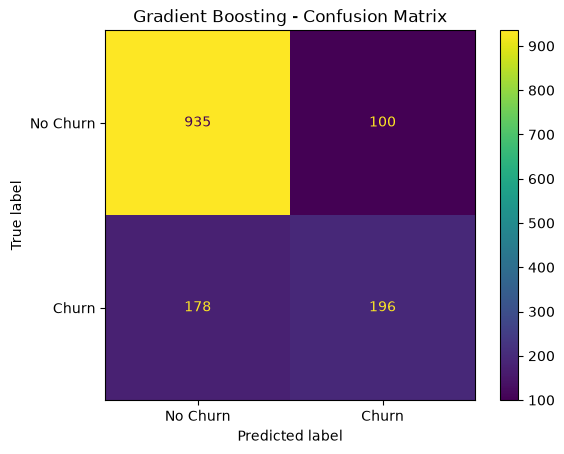

In [478]:
disp.plot()
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

Observation

The confusion matrix shows that the Gradient Boosting model correctly classifies **935 non-churn customers** and **196 churn customers**.

However, the model incorrectly classifies **100 non-churn customers as churn** and fails to identify **178 customers who actually churned**.

The relatively high number of false negatives indicates that the model misses a considerable number of customers who eventually churn. This is important 
in a customer churn problem because missed churners may represent customers who could have been targeted with retention strategies.

**8. Final Conclusions & Business Recommendations**

The analysis identified several customer groups with substantially different churn rates. The highest-risk customers tend to be associated with 
month-to-month contracts, fiber optic internet service, higher monthly charges, electronic check payments, shorter tenure, and limited additional 
services such as OnlineSecurity and TechSupport.

Among the individual models evaluated, Gradient Boosting achieved the highest ROC-AUC at 0.843, indicating the strongest ability to distinguish between 
customers who churn and those who do not. The model achieved 80% accuracy, 66% precision, 52% recall, and a 59% F1-score for the churn class.

Although Logistic Regression and Decision Tree achieved slightly higher churn F1-scores, Gradient Boosting provided the best ROC-AUC performance. 
The confusion matrix also shows that the model misses a considerable number of customers who actually churned. Therefore, the model should be viewed 
as a tool for prioritizing retention efforts rather than as a perfect prediction system.

Business Recommendations

- Focus retention efforts on month-to-month customers, particularly those using fiber optic internet, as this group shows the highest observed churn rate.

- Encourage longer-term contracts by offering incentives such as discounts, promotional pricing, or additional benefits for customers who move from month-to-month to one- or 
two-year contracts.

- Pay particular attention to new customers, since churn rates are generally higher among customers with shorter tenure. Early engagement and onboarding 
programs could help strengthen customer relationships during the first months of service.

- Review customers with high monthly charges, especially when combined with month-to-month contracts or fiber optic service. Personalized offers or plan 
reviews could help reduce perceived value gaps.

- Investigate customers using electronic check payments, as this payment method is associated with substantially higher churn. The company could 
encourage customers to switch to automatic payment methods through incentives or easier payment options.

- Promote additional support and security services, since customers without services such as OnlineSecurity and TechSupport show higher churn rates. 
Bundling relevant services could increase customer engagement and provide additional value.

- Use the churn model to prioritize retention campaigns. Customers identified as higher-risk can be targeted for proactive communication, personalized 
offers, or service reviews instead of applying the same retention strategy to every customer.

Overall, the findings suggest that an effective churn-reduction strategy should combine early customer engagement, longer-term contracts, targeted 
retention offers, improved service adoption, and data-driven identification of high-risk customers.

**10. Model Explainability — SHAP**

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the final Gradient Boosting model.

While the model predicts which customers are likely to churn, SHAP helps explain **why** a prediction is made by showing how individual features 
contribute to increasing or decreasing churn risk.

This provides greater model transparency and helps translate the machine learning results into actionable business insights.

In [482]:
import shap

In [483]:
# Transform the test data using the fitted preprocessing pipeline
X_test_transformed = grid_gb.best_estimator_['preprocessor'].transform(X_test)

In [484]:
# Get the feature names after preprocessing
feature_names = grid_gb.best_estimator_['preprocessor'].get_feature_names_out()

feature_names

array(['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges',
       'num__NumServices', 'cat__gender_Female', 'cat__gender_Male',
       'cat__SeniorCitizen_No', 'cat__SeniorCitizen_Yes',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No

In [485]:
# Create the SHAP explainer for the Gradient Boosting model
explainer = shap.TreeExplainer(
    grid_gb.best_estimator_['model']
)

In [486]:
# Calculate SHAP values for the transformed test data
shap_values = explainer.shap_values(X_test_transformed)

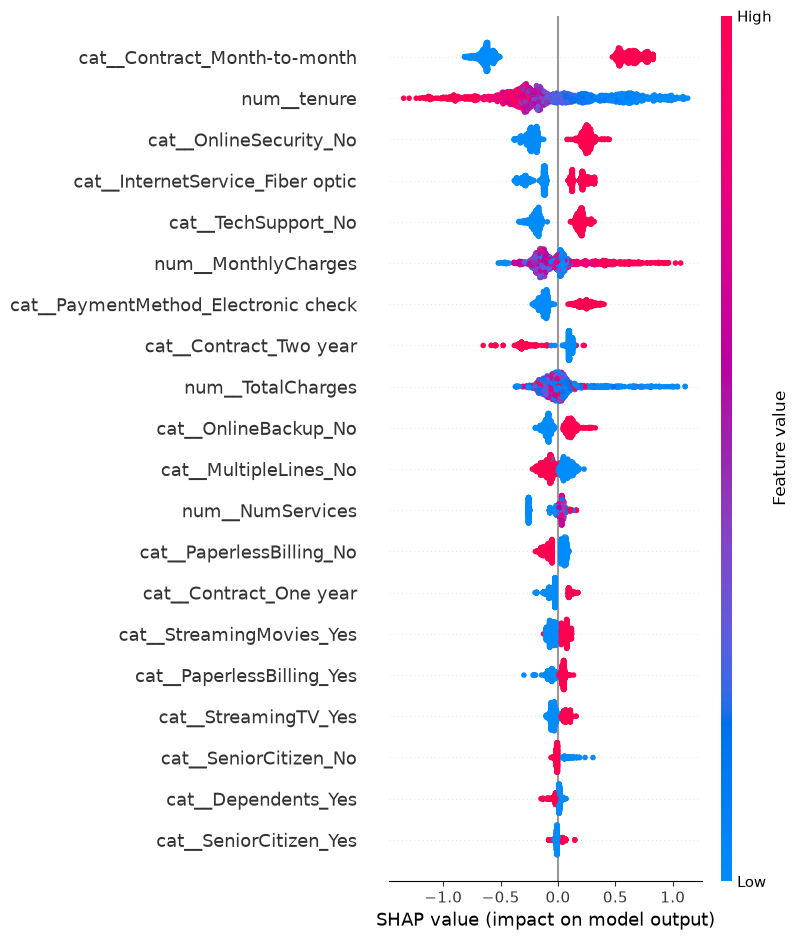

In [487]:
# Display the global feature importance using SHAP values
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

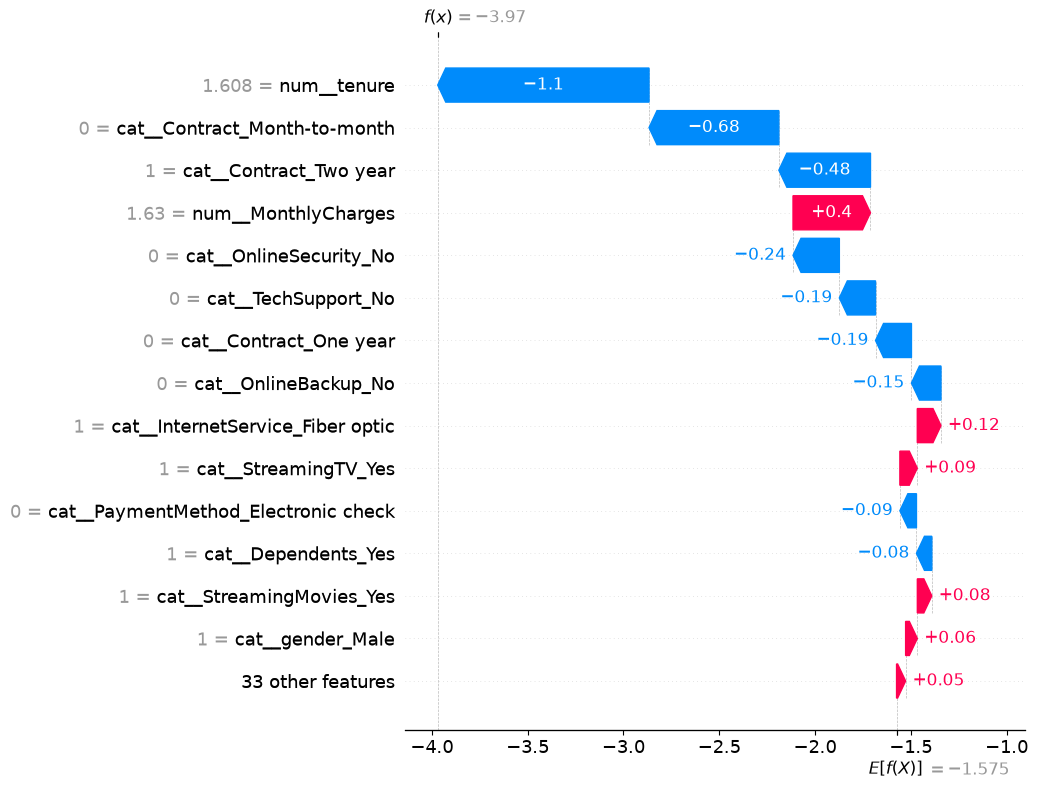

In [488]:
# Select one customer from the test set
customer_index = 0

customer_transformed = X_test_transformed[customer_index:customer_index + 1]

# Calculate SHAP values for this customer
customer_shap_values = explainer.shap_values(customer_transformed)

# Extract the scalar expected value
base_value = explainer.expected_value[0]

# Create a SHAP explanation object
customer_explanation = shap.Explanation(
    values=customer_shap_values[0],
    base_values=base_value,
    data=customer_transformed[0],
    feature_names=feature_names
)

# Display the individual customer explanation
shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

### Individual Customer Explanation

The SHAP waterfall plot shows how the model's features contribute to the churn prediction for one individual customer.

For this customer, **tenure, contract type, and security/support services** are the strongest factors pushing the prediction toward lower churn risk. In contrast, **higher monthly charges, fiber optic internet service, and streaming TV** contribute to higher predicted churn risk.

The SHAP values explain the model's prediction for this specific customer and should not be interpreted as causal effects.